# Assignment 1: Transformers & Generative Pretrained Transformer (GPT)

The goal of this assignment is to master the **Transformer architecture**, which is the engine behind modern Large Language Models (LLMs) such as ChatGPT, Gemini, and DeepSeek. We will implement a compact, decoder-only transformer from scratch, closely following the [NanoGPT](https://github.com/karpathy/nanoGPT) project by Andrej Karpathy.

We will train this model on textual figure captions from the [Open-MELON dataset](https://huggingface.co/datasets/MartiHan/Open-MELON-VL-2.5K), which contains descriptions of histopathology images (specifically melanocytic lesions). After training, your model will be able to generate **synthetic captions** when prompted with a short starting sequence. Note that at this point we do not associate these captions with image data. We will go into vision-language models that can jointly model both image and text data in the next assignment. For now, we focus on text, but, as you will see in Assignment 2, extending the Transformer architecture to model image data is a straightforward extension.

This dataset was specifically prepared for this course (work done by Martina Hanusova). While this dataset is certainly not as large as the massive corpora used to train ChatGPT and consists of open-access figures and captions rather than medical images and clinical reports, it offers two  advantages. First, the content is highly dense with relevant medical terminology, which makes the training process efficient. Second, because we are using public data from medical publications, we avoid the complex legal and ethical hurdles associated with handling private patient data.

## Preparation

We start with the assumption that you have a solid understanding of fundamental machine learning and neural network concepts, such as linear regression, gradient descent, backpropagation, and loss functions; if you need a refresher, please review materials from the previous courses (e.g. 8BB020 Introduction to Machine Learning). You must prepare for this assignment by mastering the Transformer architecture, specifically understanding self-attention mechanisms in neural networks and the distinction between encoder models and the decoder-only architectures (like GPT) used for generative tasks.

Beyond the architecture, you must also familiarize yourself with the basics of Computational Pathology to understand the medical context of our dataset (we will be generating captions for H&E stained histopathology images).

This is a list of materials that you can use to learn the topic of Transformers and prepare for the flipped classrooms:

| Type | Length | Link | Why is it relevant? |
| :--- | :--- | :--- | :--- |
| Video | 8 min. | [Large Language Models explained briefly (3Blue1Brown)](https://www.youtube.com/watch?v=LPZh9BOjkQs&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=5) | This video from the [3Blue1Brown](https://www.3blue1brown.com/) YouTube channel was originally made as an exhibit for Computer History Museum. It gives a very "gentle" and high-level introduction of the mechanics of how (large) language models work and are trained. This includes the concept of autoregressive modelling (predicting the next word in a sequence), (pre)-training of large language models from text datasets (the "P" in GPT stands for "pretrained") as well as reinforcement learning with human feedback. While in this course we will keep to training of (relatively small) language models, it is good to have the complete picture.  The entire 3Blue1Brown channel is a very high-quality source of educational content on a wide range of topics. In fact, the entire [Neural networks]() playlist is highly recommended, also as a refresher to more fundamental concepts such as backpropagation. |
| Paper | 10 pg. | [Attention Is All You Need (Vaswani et al.)](https://arxiv.org/abs/1706.03762) | This is the paper that introduced the Transformer architecture to the world. It is a must-read for anyone interested in the subject. The paper is relatively short (10 pages without references), however it can be a bit "dense" for beginners. That is ok, as the most important thing to understand is the tokenization of text and the self-attention mechanism. Both of these concepts are also covered in the next two recommended videos so it is best that you iterate between watching the videos and reading the paper. Note that one thing that might be particularly confusing is that the neural network architecture in this paper has both an encoder and decoder part. This is because the application that is addressed here is natural language translation (machine translation). In this setup, the encoder part is used to encode the text in the original language and the decoder is used to translate this encoded text into the target language. In this course we will focus on decoder-only architectures, which are used for generative tasks such as text generation. |
| Video | 27 min. | [Transformers, the tech behind LLMs (3Blue1Brown)](https://www.youtube.com/watch?v=wjZofJX0v4M&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) | This video provides a visual overview of the data flow within a Transformer, specifically focusing on GPT-style (decoder-only) models. It explains tokenization, embeddings (how vectors encode semantic meaning), and the final softmax layer used to predict the next token. It serves as a high-level roadmap of the architecture before diving into specific components in the next video. |
| Video | 26 min. | [Attention in transformers (3Blue1Brown)](https://www.youtube.com/watch?v=eMlx5fFNoYc&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) |This chapter breaks down the Attention mechanism (Self-Attention), which is the core innovation of the Transformer. It details the Query, Key, and Value (Q, K, V) matrices and visualizes how the attention pattern is calculated via dot products. It explains how the model uses these to "attend" to relevant context (updating word meanings based on surrounding words) and introduces concepts like multi-head attention and masking. |
| Interactive tool | ~25 min. | [Transformer explainer (poloclub)](https://poloclub.github.io/transformer-explainer/)| This is a great interactive tool that explains in steps how transformer models for language work and make predictions. It should take around 25 minutes to go over all the steps in the tool for one example, but it might be useful to spend some more time and look at different examples. |
| Video | 120 min. | [Let's build GPT: from scratch, in code, spelled out (Andrej Karpathy)](https://www.youtube.com/watch?v=kCc8FmEb1nY) | This video series provides a step-by-step guide to building a GPT-style transformer from scratch. It covers the entire process, from data preparation to model training and evaluation. It is a great resource for understanding the mechanics of how GPT-style models work and how to implement them in code. It is **optional** in a sense that it is not required for the exercises, but might be very useful for understanding the dataset and **formulating an research question for the open assignment.** |
| Paper | 11 pg. | [From melanocytes to melanomas (Shain et al.)](https://www.nature.com/articles/nrc.2016.37) | This review paper provides a good overview of the biology of melanocytic lesions and the histopathology of melanocytic lesions. It is a good resource to understand the medical context of our dataset.|
| Paper | 35 pg. | [Large Language Models: A Survey (Minaee et al.)](https://arxiv.org/abs/2402.06196) | This survey paper is a good resource to get the "big picture" of various large language models and how they differ in their methodology and implementation. Treat this resource as **optional**. It is not required to complete the exercises in this assignments, but it is very useful to get a broader understanding of the state-of-the-art, which you might find useful for **generating ideas for the open assignment** or future projects (e.g. for your BEP or MSc projects). |

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


CUDA available: True
GPU name: Tesla T4


In [ ]:
print(cfg.device)

NameError: name 'cfg' is not defined

## Exercises: Theory

⚠️ *The answers to the theory exercises are NOT to be submitted as part of the assignment deliverables. They can, however, be used to check your understanding of the materials and to prepare for the flipped classroom. You CAN include your discussion about the exercises in the flipped classroom log.*

#### Exercise T.1

A GPT model is autoregressive, meaning it generates text strictly one token at a time. It predicts the first next token, appends it to the sequence, and uses that updated sequence to predict the second token. This is a serial process.

In contrast, many other neural networks process their entire input in parallel (all at once) to maximize speed.

If we modified the architecture to predict every token in a paragraph simultaneously (in parallel) rather than one by one, is the resulting text likely to be grammatically coherent? Explain your reasoning.

#### Exercise T.2

In this assignment (as you will see later), we define tokens to be individual characters (e.g., 'a', 'b', 'c'). This keeps our vocabulary small and the implementation simple. In contrast, the standard practice for modern Large Language Models is to use sub-word tokenization, which groups frequent character patterns into single tokens to process text more efficiently.

Assume that we take this concept one step further and define tokens to be entire sentences. What would be the consequence of this when generating text?

#### Exercise T.3

The core concept of a Transformer is self-attention, which allows a token to look at other tokens to gather context. In a Decoder-only model (like GPT), we apply a specific constraint called Causal Self-Attention (or "Masked" Self-Attention) during training. This forces every token to look only at itself and the tokens that came before it.

This is different from Encoder models, which use Bidirectional Attention, allowing tokens to see the entire sentence (past and future) at once.

Assume that during training, we feed the entire completed sentence into the model at once. Will this model still be useful for generating text? Explain your reasoning.

#### Exercise T.4

Decoder-only models (like GPT) are mathematically optimized to maximize the probability of the text sequence. This means that if they were trained with medical report data, they strive to generate text that "looks" and "sounds" like a real medical report. They are not optimized to check for factual truth.

Assume that your trained model generates a synthetic pathology caption that includes specific quantitative details: "The sample shows a high mitotic rate of 8 figures per 10 HPF."

Why is this specific type of error (a plausible-sounding number) significantly more dangerous to a clinician than if the model had just generated obvious gibberish (e.g., "rate figures high 8 10" )?

#### Exercise T.5

If we want to train a model that generates a pathology report based on medical imaging data, we would need a joint vision-language model. We will touch on this in the next assignment. For now, assume that we want to generate a report based on some medical test or observations that we can represent as text data and make them part of the starting sequence that we use to prompt further generation.

Consider the following example of how such a model would operate:

Input Sequence (Provided by User): "Clinical Indication: Patient has a rapidly growing, asymmetrical black lesion on the left shoulder. Rule out Melanoma. Gross Description: ..."

Generated Continuation (Predicted by Model): "...Specimen consists of a skin ellipse measuring 2.0 x 1.5 cm. Microscopic examination reveals a proliferation of atypical melanocytes arranged in nests at the dermo-epidermal junction. There is upward migration of cells (pagetoid spread). DIAGNOSIS: MALIGNANT MELANOMA."

Would such a model be useful in clinical practice? Motivate your answer.


## Before you Begin...

### Dataset

[Open-MELON-VL-2.5K](https://huggingface.co/datasets/MartiHan/Open-MELON-VL-2.5K) is a vision–language dataset of 2,500 Hematoxylin & Eosin-stained histopathology images of melanocytic lesions with captions, curated from PubMed open-access publications. It is hosted on Hugging Face, which is a platform for sharing and accessing datasets.

### GPU Usage

For the assignments, we recommend to use GPU for faster model training or evaluation.
[Google Colab](https://colab.research.google.com) provides a free service for hosting Jupyter notebooks allowing to access a remote Tesla T4 GPU.
Please keep in mind the Colab free tier GPU usage limits (approximately 1.5 hours per day, but may be higher or lower depending on your usage history).

To enable a GPU in Colab, navigate to the menu panel -> `Runtime` -> `Change runtime type` -> `T4 GPU` -> `Save`.
When you are done with your work, detach the current runtime session and download the Jupyter notebook file locally.

⚠️ *Note that all assignments are designed to also be doable on the CPUs of your laptops, so you do not have to use Colab or a GPU.*

## Training a Generative Language Model

### Install Required Packages

This notebook uses:
- `numpy` for basic math operations
- `datasets` to load captions from Hugging Face
- PyTorch to implement NanoGPT-like model + training loop
- `tqdm` for displaying progress bars

All other used packages should already be available on your system. If you need help with setting up your Python environment, please ask help from your assigned TA.

Let's install the required packages:

In [ ]:
!pip install numpy datasets torch tqdm

### Import the Libraries

The following Python modules will be used for our NanoGPT implementation.

In [ ]:
import os
import math
import random
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np

from datasets import load_dataset, concatenate_datasets

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm

### Load the Dataset

In the code block below, [Open-MELON dataset](https://huggingface.co/datasets/MartiHan/Open-MELON-VL-2.5K) is loaded using HuggingFace loaders and the figure captions are concatenated into one big training corpus.


In [ ]:
# ds_dict is a list of ['train', 'validation', 'test'] splits
ds_dict = load_dataset("MartiHan/Open-MELON-VL-2.5K")

# in this example, all 3 splits are concatenated
# validation set is later drawn from the text chunks of 'block_size'
ds_all = concatenate_datasets(list(ds_dict.values()))

captions = [str(x) for x in ds_all["caption"]]
print("Captions:", len(captions))
print("Example caption:", captions[0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/415M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/143M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1726 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/375 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/398 [00:00<?, ? examples/s]

Captions: 2499
Example caption: Small bowel polyps showing malignant cells located at the lamina propria and submucosa. The image is stained with hematoxylin and eosin (H&E) at × 4 magnification.


#### Preprocess the Training Text

We join separate captions with `<ENDC>` separator. This helps the model learn boundaries.


In [ ]:
SEP = "\n<ENDC>\n"
text = SEP.join(captions)

# Print the total number of characters in the dataset
print("Training text length (chars):", len(text))

# Print the first 1000 characters of the constructed text corpus
print(text[:1000])

Training text length (chars): 971654
Small bowel polyps showing malignant cells located at the lamina propria and submucosa. The image is stained with hematoxylin and eosin (H&E) at × 4 magnification.
<ENDC>
Histopathology of small bowel polyps showing malignant cells arranged in diffuse sheets with the presence of intracytoplasmic and extracellular pigments. The image is stained with hematoxylin and eosin (H&E) at × 20 magnification.
<ENDC>
Small bowel polyps showing malignant cells located at the lamina propria and submucosa. The image is stained with hematoxylin and eosin (H&E) at × 4 magnification.
<ENDC>
Histopathology showing spindle cell uveal melanoma from a left eye choroidal pigmented malignant melanoma, classified as invasive in the ciliary body and cornea (stage IIIB, pT4bN0M0). The microscopic examination reveals a dense cell proliferation composed of small and medium fusiform (spindle) cells, along with evident pigment production. The tissue fragments were embedded in par

### Character-level Tokenizer

We build a vocabulary of unique characters from the training text.


In [ ]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

# mapping of characters to numerical tokens (by their order in vocabulary alphabet)
stoi = {ch:i for i,ch in enumerate(chars)}

# mapping of numerical tokens back to characters
itos = {i:ch for i,ch in enumerate(chars)}

def encode(s: str):
    """
    Converts character to a token.
    Input: character (e.g. 'A')
    Output: numerical token (e.g. 65)
    """
    return [stoi[c] for c in s]

def decode(ids):
    """
    Converts token to a character.
    Input: numerical token (e.g. 65)
    Output: character (e.g. 'A')
    """
    return "".join(itos[i] for i in ids)

Let's print some information about the vocabulary that we have created as well as some examples of encoding words.

In [ ]:
print("Size of the vocabulary:", vocab_size)
print("Preview of the vocabulary:", chars)

examples = ["male", "malignant", "melanoma", "malignant melanoma"]

print("\n--- Encoding Examples ---")

for word in examples:
    tokens = encode(word)

    # Create a visual mapping of Char -> Token
    mapping_str = ", ".join([f"'{c}':{t}" for c, t in zip(word, tokens)])

    print(f"String:  {word}")
    print(f"Tokens:  {tokens}")
    print(f"Mapping: {mapping_str}")
    print("-" * 40)


Size of the vocabulary: 109
Preview of the vocabulary: ['\n', ' ', '"', '#', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', '^', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '\xa0', '§', '°', '±', '²', '´', 'µ', '×', 'í', 'α', 'μ', '\u2005', '\u2009', '‐', '–', '‘', '’', '“', '”', '→', '⇒', '≤', '≥', '⊷']

--- Encoding Examples ---
String:  male
Tokens:  [71, 59, 70, 63]
Mapping: 'm':71, 'a':59, 'l':70, 'e':63
----------------------------------------
String:  malignant
Tokens:  [71, 59, 70, 67, 65, 72, 59, 72, 78]
Mapping: 'm':71, 'a':59, 'l':70, 'i':67, 'g':65, 'n':72, 'a':59, 'n':72, 't':78
----------------------------------------
String:  melanoma
Tokens:  [71, 63, 70, 59, 72, 73,

Now we encode the text corpus and store it as PyTorch array. The first 90% of this array will be used for training, while the remaining 10% will be used for validation.

In [ ]:

data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split: str):
    src = train_data if split == "train" else val_data
    ix = torch.randint(len(src) - cfg.block_size - 1, (cfg.batch_size,))
    x = torch.stack([src[i:i+cfg.block_size] for i in ix])
    y = torch.stack([src[i+1:i+cfg.block_size+1] for i in ix])
    return x.to(cfg.device), y.to(cfg.device)

print("Train tokens:", train_data.numel(), "Val tokens:", val_data.numel())

Train tokens: 874488 Val tokens: 97166


### Model Training Configurations

The following configuration classes define the size of the transformer model and how it is trained. These hyperparameters control model capacity, context length, training stability, and computational cost. You can later use this to perform different experiments, e.g. comparing models of different size (capacity) and context length.

**Model configuration**

- `vocab_size` - number of unique tokens the model can process. In this assignment, tokens are individual characters, so the vocabulary size equals the number of distinct characters in the training corpus.

- `block_size` - the context window length, i.e. the maximum number of tokens the model can see at once. During training and generation, the model predicts the next token using only the previous block_size tokens. A larger block size allows the model to capture longer-range dependencies but increases memory and computation requirements.

- `n_layer` - number of stacked transformer decoder blocks. More layers increase model depth and expressiveness but also training time and risk of overfitting.

- `n_head` - number of attention heads in each self-attention layer. Multiple heads allow the model to attend to different aspects of the context simultaneously (e.g. syntax, formatting, or local patterns).

- `n_embd` - dimensionality of token embeddings and hidden representations. Larger embeddings allow richer representations but increase memory usage and compute cost.

- `dropout` - dropout probability used during training as a regularization technique. It helps prevent overfitting by randomly deactivating neurons. Dropout is disabled for CPU training to keep behavior deterministic and training stable.

**Training configuration**
- `batch_size` - Number of training sequences processed in parallel during one optimization step. Larger batches improve gradient stability but require more memory.

- `max_iters` - total number of training iterations (parameter update steps).

- `eval_interval` - number of training iterations between evaluations on the validation set.

- `eval_iters` - number of mini-batches used to estimate training and validation loss during evaluation.

- `lr (learning rate)` - step size used by the optimizer when updating model parameters. This is one of the most sensitive hyperparameters for training stability.

- `weight_decay` - regularization term that penalizes large weights and helps reduce overfitting.

- `device` - specifies whether training runs on CPU or GPU. Smaller model and batch sizes are used automatically when no GPU is available.


In [ ]:
##############################################################################################
### Model configuration (number of layers, number of heads, embedding dimensions, dropout) ###
##############################################################################################

# Configuration for GPU
@dataclass
class ModelConfigGPU:
    vocab_size: int
    block_size: int
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 256
    dropout: float = 0.2

# Configuration for CPU
@dataclass
class ModelConfigCPU:
    vocab_size: int
    block_size: int
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0

########################################################################################################
### Model configuration (block size, batch size, evaluation iterations, learning rate, weight decay) ###
########################################################################################################

# Configuration for GPU
@dataclass
class TrainConfigGPU:
    block_size: int = 256
    batch_size: int = 64
    max_iters: int = 2000
    eval_interval: int = 250
    eval_iters: int = 200
    lr: float = 1e-3
    weight_decay: float = 0.1
    device: str = "cuda"

# Configuration for CPU
@dataclass
class TrainConfigCPU:
    block_size: int = 64
    batch_size: int = 12
    max_iters: int = 2000
    eval_interval: int = 200
    eval_iters: int = 50
    lr: float = 1e-3
    weight_decay: float = 0.1
    device: str = "cpu"
    compile: bool = False


# Automatically select suitable configuration based on GPU detection
if torch.cuda.is_available():
  ModelConfig = ModelConfigGPU
  TrainConfig = TrainConfigGPU
else:
  ModelConfig = ModelConfigCPU
  TrainConfig = TrainConfigCPU


### Building the NanoGPT Model

The model begins with token embeddings, which map character indices to dense vectors, and positional embeddings, which encode the order of tokens within a fixed context window (`block_size`). These embeddings are added together and passed through a stack of transformer decoder blocks.

Each decoder block consists of two main submodules: causal self-attention and a feed-forward network (MLP). Causal self-attention allows each token to attend only to previous tokens by applying a causal mask, ensuring that the model cannot access future information during training or generation. Multiple attention heads are used so that the model can focus on different aspects of the context in parallel. The MLP applies a non-linear transformation independently at each position, complementing the attention mechanism. Layer normalization and residual connections are used throughout to stabilize training and preserve information flow.


In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        assert c.n_embd % c.n_head == 0
        self.n_head = c.n_head
        self.head_dim = c.n_embd // c.n_head

        self.qkv = nn.Linear(c.n_embd, 3 * c.n_embd, bias=False)
        self.proj = nn.Linear(c.n_embd, c.n_embd, bias=False)
        self.dropout = nn.Dropout(c.dropout)

        mask = torch.tril(torch.ones(c.block_size, c.block_size)).view(1, 1, c.block_size, c.block_size)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=2)

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.proj(y)
        y = self.dropout(y)
        return y

class MLP(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        self.fc = nn.Linear(c.n_embd, 4 * c.n_embd)
        self.proj = nn.Linear(4 * c.n_embd, c.n_embd)
        self.dropout = nn.Dropout(c.dropout)

    def forward(self, x):
        x = self.fc(x)
        x = F.gelu(x)
        x = self.proj(x)
        x = self.dropout(x)
        return x

class Block(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(c.n_embd)
        self.attn = CausalSelfAttention(c)
        self.ln2 = nn.LayerNorm(c.n_embd)
        self.mlp = MLP(c)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

After passing through all decoder blocks, the model applies a final layer normalization and a linear output head that produces a probability distribution over the vocabulary for the next-token prediction. The training objective is standard cross-entropy loss between the predicted next token and the true next token.

This NanoGPT model contains approximately between 0.8 and 3 million parameters, depending on the configuration. By comparison, GPT-2 contains hundreds of millions of parameters and modern commercial language models contain many billion parameters. Despite this difference in scale, the same architectural principles apply. The total number of parameters is mainly determined by the embedding dimension (`n_embd`), the number of layers (`n_layer`), and the vocabulary size, while the number of attention heads controls how the embedding space is partitioned rather than its overall size.

The model is intentionally kept small so that it can be trained quickly on limited hardware and easily inspected. The goal of this assignment is to understand how transformer components interact, not to achieve state-of-the-art language modeling performance.

In [ ]:
class NanoGPT(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        self.c = c
        self.tok_emb = nn.Embedding(c.vocab_size, c.n_embd)
        self.pos_emb = nn.Embedding(c.block_size, c.n_embd)
        self.drop = nn.Dropout(c.dropout)
        self.blocks = nn.ModuleList([Block(c) for _ in range(c.n_layer)])
        self.ln_f = nn.LayerNorm(c.n_embd)
        self.head = nn.Linear(c.n_embd, c.vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.c.block_size
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)

        x = self.tok_emb(idx) + self.pos_emb(pos)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

cfg = TrainConfig()
mcfg = ModelConfig(vocab_size=vocab_size, block_size=cfg.block_size)

model = NanoGPT(mcfg).to(cfg.device)
print("Parameters:", sum(p.numel() for p in model.parameters())/1e6, "M")


Parameters: 3.2768 M


### The Training Loop

We use the AdamW optimizer and periodically evaluate on the validation set. The training in Google Colab should take for both the CPU and GPU configurations approximately 4-5 minutes using the baseline configuration.

In [ ]:
@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(cfg.eval_iters)
        for k in range(cfg.eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

model.train()
pbar = tqdm(range(cfg.max_iters), desc="training")
for it in pbar:
    if it % cfg.eval_interval == 0:
        losses = estimate_loss()
        pbar.set_postfix(train=losses["train"], val=losses["val"])

    xb, yb = get_batch("train")
    _, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()


training:   0%|          | 0/2000 [00:00<?, ?it/s]

### Text Generation (Sampling)

Now that the model is trained we can put it to use. We generate the synthetic captions starting from `"H&E stained section showing"` string by autoregressively sampling next characters

Hyperparameters:
- `temperature`: higher = more random, lower = less variety
- `top_k`: restrict sampling to top-k most likely chars (lower number eliminates less likely candidates)

In [ ]:
@torch.no_grad()
def generate(start: str, max_new_tokens=400, temperature=1.0, top_k=60):
    model.eval()
    idx = torch.tensor([encode(start)], dtype=torch.long, device=cfg.device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -cfg.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / max(temperature, 1e-6)

        if top_k is not None:
            v, _ = torch.topk(logits, k=min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float("Inf")

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

    return decode(idx[0].tolist())

prompt = "H&E stained section showing"

print(generate(prompt, max_new_tokens=500, temperature=0.7, top_k=10))


H&E stained section showing a commonly fibrous histological analysis of melanoma. Stained with hematoxylin and eosin (H&E).
<ENDC>
Histopathology showing a proliferative specimen from the basal cells. The image is stained with Hematoxylin and eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology of a lesion from a 61-year-old female, showing the positive fibrosis (Hematoxylin and Eosin (H&E) at 10000x magnification.
<ENDC>
Histopathology showing atypical Spitz tumor (MMNS) with conjunctival nests of the epithelium (H&E


⚠️ *Everything below this line must be submitted as a deliverable for this assignment.*

ℹ️ *Answering the exercises below will require you to implement new code and/or modify the code in cells above. You can add the code directly in the notebook or in separate Python files, depending on your preference. If you write code in separate files, please do not forget to also submit them. The exercises will also require re-running the training, sometimes multiple times. You can split the workload among the group members so things are done more efficiently.*

## Exercises: Practice

#### Exercise 1

When we created the text corpus, we used the <ENDC> separator to mark the end of a caption. Why is the <ENDC> separator needed? What would happen if you use a model trained without such separator in practice? In order to investigate this, train a model without the <ENDC> separator and compare the results with the model trained with the <ENDC> separator when generating captions.

#### Exercise 2

Train the model and plot training loss and validation loss as a function of training iterations. Modify the following hyperparameters and observe the effect:
- Learning rate
- Batch size
- Evaluation interval

Explain why the observed changes occur. What patterns indicate underfitting? What patterns suggest overfitting or unstable training?

#### Exercise 3

We can reduce the number of tokens by converting all letters to either uppercase or lowercase. Implement this in the preprocessing function and retrain a model. Report your observations on the training and performance of the model.


#### Exercise 4

The dataset contains 2500 figure captions. After encoding and splitting out 10% of the tokens for validation, we are left with 874488 training tokens. Is this also the number of training samples used to train our NanoGPT model? If yes, explain why, if not try to estimate the actual number of training samples.

#### Exercise 5

Text generation depends strongly on the sampling hyperparameters.

Generate captions using at least three different temperature values and two different top_k values. Include at least 10 generated examples per hyperparameter configuration in your report.

For each configuration, comment on the following characteristics of the generated samples:
  - Fluency and structure
  - Repetition or degeneration
  - Factual plausibility (even if the content is synthetic)

Identify optimal configuration of parameters that balances coherence and diversity of the produced synthetic captions, and justify your choice.

## Flipped Classroom Log

ℹ️ *You have to fill this log for both flipped classroom sessions for this assignment. You only fill the log for your group, not together with the group that you interacted with.*

### Instructions

#### Preparation
* **Clients:** List specific theoretical or implementation (code) questions prepared before class.
* **Consultants:** List papers, videos, or code documentation reviewed to prepare. Note, this is not limited to the material listed above, you can add any new material that you used or found useful.

#### Peer Interaction
* **Clients:** Summarize the solutions or explanations received.
* **Consultants:** Summarize advice given and specific resources shared.



### Logs
#### First Flipped Classroom



ℹ️ *Write the log for your group in this cell. Should be in a narrative style, aim for a max. of 600 words.*

**Role**: Client/Consultant

**Description** of activities during flipped classroom:

#### Second Flipped Classroom


ℹ️ *Write the log for your group in this cell. Should be in a narrative style, aim for a max. of 600 words.*

**Role**: Client/Consultant

**Description** of activities during flipped classroom:

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)


CUDA available: True
GPU: Tesla T4
CUDA version: 12.6


In [ ]:
!pip -q install numpy datasets torch tqdm


In [ ]:
import random
from dataclasses import dataclass, replace
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device: str = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [ ]:
@dataclass(frozen=True)
class ExpConfig:
    block_size: int
    batch_size: int
    max_iters: int
    eval_interval: int
    eval_iters: int
    lr: float
    weight_decay: float
    device: str

def get_batch_cfg(cfg: ExpConfig, split: str) -> Tuple[torch.Tensor, torch.Tensor]:
    src: torch.Tensor = train_data if split == "train" else val_data
    ix: torch.Tensor = torch.randint(len(src) - cfg.block_size - 1, (cfg.batch_size,))
    x: torch.Tensor = torch.stack([src[i : i + cfg.block_size] for i in ix])
    y: torch.Tensor = torch.stack([src[i + 1 : i + cfg.block_size + 1] for i in ix])
    return x.to(cfg.device), y.to(cfg.device)

@torch.no_grad()
def estimate_loss_cfg(model: torch.nn.Module, cfg: ExpConfig) -> Dict[str, float]:
    model.eval()
    out: Dict[str, float] = {}
    for split in ["train", "val"]:
        losses: torch.Tensor = torch.zeros(cfg.eval_iters)
        for k in range(cfg.eval_iters):
            xb, yb = get_batch_cfg(cfg, split)
            _, loss = model(xb, yb)
            losses[k] = float(loss.item())
        out[split] = float(losses.mean().item())
    model.train()
    return out


In [ ]:
def run_experiment(
    name: str,
    base_cfg: ExpConfig,
    model_cfg,  # your ModelConfig instance type from the notebook
    seed: int = 42,
    run_training: bool = True,
) -> Dict[str, List[float]]:
    """
    Returns history dict with:
      - "iters": list of iteration indices
      - "train": train losses
      - "val": validation losses
    """
    print(f"\n=== Running: {name} ===")
    set_seed(seed)

    # IMPORTANT: fresh model + optimizer per experiment
    model = NanoGPT(model_cfg).to(base_cfg.device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=base_cfg.lr,
        weight_decay=base_cfg.weight_decay,
    )

    it_hist: List[int] = []
    train_hist: List[float] = []
    val_hist: List[float] = []

    if not run_training:
        print("run_training=False -> skipping training (safety mode).")
        return {"iters": it_hist, "train": train_hist, "val": val_hist}

    for it in range(base_cfg.max_iters + 1):
        if it % base_cfg.eval_interval == 0:
            losses = estimate_loss_cfg(model, base_cfg)
            it_hist.append(it)
            train_hist.append(losses["train"])
            val_hist.append(losses["val"])
            print(f"iter {it:4d} | train {losses['train']:.4f} | val {losses['val']:.4f}")

        if it == base_cfg.max_iters:
            break

        xb, yb = get_batch_cfg(base_cfg, "train")
        _, loss = model(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    return {"iters": it_hist, "train": train_hist, "val": val_hist}


In [ ]:
# Baseline training config (matches the spirit of your GPU config)
base_cfg: ExpConfig = ExpConfig(
    block_size=256,
    batch_size=64,
    max_iters=2000,
    eval_interval=250,
    eval_iters=200,
    lr=1e-3,
    weight_decay=0.1,
    device=device,
)

# IMPORTANT: model block_size must match cfg.block_size
# vocab_size should already exist from your tokenizer cell.
model_cfg = ModelConfig(vocab_size=vocab_size, block_size=base_cfg.block_size)

# Safety switch: keep False until you're ready
RUN_ALL_EXPERIMENTS: bool = True

experiments: List[Tuple[str, ExpConfig]] = [
    ("baseline", base_cfg),
    ("lr_low_1e-4", replace(base_cfg, lr=1e-4)),
    ("lr_high_3e-3", replace(base_cfg, lr=3e-3)),
    ("batch_small_16", replace(base_cfg, batch_size=16)),
    ("eval_interval_50", replace(base_cfg, eval_interval=50)),
]

all_histories: Dict[str, Dict[str, List[float]]] = {}

for exp_name, cfg_i in experiments:
    # if block_size changes, you MUST also rebuild model_cfg to match
    cfg_model = ModelConfig(vocab_size=vocab_size, block_size=cfg_i.block_size)
    hist = run_experiment(
        name=exp_name,
        base_cfg=cfg_i,
        model_cfg=cfg_model,
        seed=42,
        run_training=RUN_ALL_EXPERIMENTS,
    )
    all_histories[exp_name] = hist

print("Done. Experiments:", list(all_histories.keys()))



=== Running: baseline ===
iter    0 | train 4.7385 | val 4.7375
iter  250 | train 1.8905 | val 1.9267
iter  500 | train 1.0355 | val 1.1075
iter  750 | train 0.8396 | val 0.9411
iter 1000 | train 0.7365 | val 0.8731
iter 1250 | train 0.6752 | val 0.8393
iter 1500 | train 0.6290 | val 0.8161
iter 1750 | train 0.5965 | val 0.8048
iter 2000 | train 0.5598 | val 0.7977

=== Running: lr_low_1e-4 ===
iter    0 | train 4.7385 | val 4.7375
iter  250 | train 2.3696 | val 2.3920
iter  500 | train 2.1554 | val 2.1830
iter  750 | train 1.8240 | val 1.8498
iter 1000 | train 1.5218 | val 1.5710
iter 1250 | train 1.3209 | val 1.3814
iter 1500 | train 1.1665 | val 1.2372
iter 1750 | train 1.0682 | val 1.1484
iter 2000 | train 0.9971 | val 1.0915

=== Running: lr_high_3e-3 ===
iter    0 | train 4.7385 | val 4.7375
iter  250 | train 2.4931 | val 2.5166
iter  500 | train 2.1899 | val 2.2138
iter  750 | train 1.4800 | val 1.5198
iter 1000 | train 0.9743 | val 1.0584
iter 1250 | train 0.8224 | val 0.9373


Excersise 2

Saved plot to: /content/drive/MyDrive/transformer_assignment/exercise2_loss_comparison.png


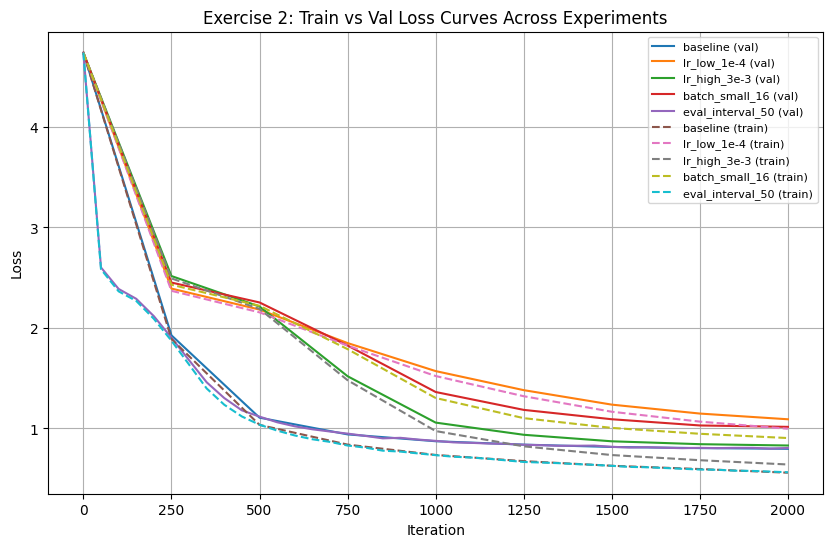

In [ ]:
def plot_all_histories(histories: Dict[str, Dict[str, List[float]]], save_path: Optional[str] = None) -> None:
    plt.figure(figsize=(10, 6))

    # Plot validation as solid lines (easier to compare generalization)
    for name, h in histories.items():
        if len(h["iters"]) == 0:
            continue
        plt.plot(h["iters"], h["val"], label=f"{name} (val)")

    # Plot training as dashed lines
    for name, h in histories.items():
        if len(h["iters"]) == 0:
            continue
        plt.plot(h["iters"], h["train"], linestyle="--", label=f"{name} (train)")

    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Exercise 2: Train vs Val Loss Curves Across Experiments")
    plt.legend(fontsize=8)
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved plot to:", save_path)

    plt.show()

plot_all_histories(
    all_histories,
    save_path=f"{save_dir}/exercise2_loss_comparison.png"
)


In [ ]:
import json

with open("exercise2_histories.json", "w") as f:
    json.dump(all_histories, f)

print("Saved histories to exercise2_histories.json")


Saved histories to exercise2_histories.json


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

save_dir = "/content/drive/MyDrive/transformer_assignment"
os.makedirs(save_dir, exist_ok=True)

print("Saving to:", save_dir)


Saving to: /content/drive/MyDrive/transformer_assignment


In [ ]:
import json

with open(f"{save_dir}/exercise2_histories.json", "w") as f:
    json.dump(all_histories, f)

print("Saved:", f"{save_dir}/exercise2_histories.json")


Saved: /content/drive/MyDrive/transformer_assignment/exercise2_histories.json


Saved plot to: /content/drive/MyDrive/transformer_assignment/exercise2_loss_comparison_REPLOT.png


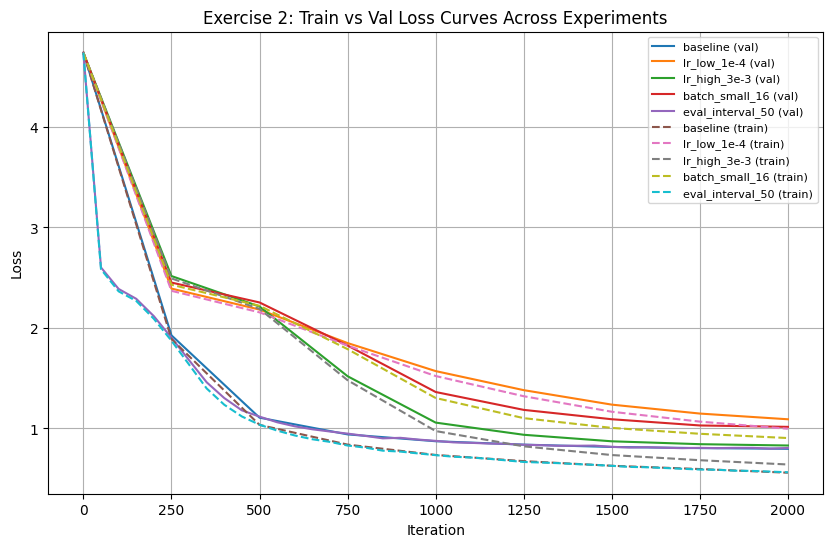

In [ ]:
import json

with open(f"{save_dir}/exercise2_histories.json", "r") as f:
    loaded_histories = json.load(f)

plot_all_histories(loaded_histories, save_path=f"{save_dir}/exercise2_loss_comparison_REPLOT.png")


In [ ]:
import json

with open(f"{save_dir}/exercise2_histories.json", "r") as f:
    h = json.load(f)

for name, d in h.items():
    if len(d["iters"]) == 0:
        print(name, "-> no data")
        continue
    print(
        f"{name:18s} | last iter {d['iters'][-1]:4d} | "
        f"train {d['train'][-1]:.4f} | val {d['val'][-1]:.4f}"
    )


baseline           | last iter 2000 | train 0.5598 | val 0.7977
lr_low_1e-4        | last iter 2000 | train 0.9971 | val 1.0915
lr_high_3e-3       | last iter 2000 | train 0.6417 | val 0.8306
batch_small_16     | last iter 2000 | train 0.9048 | val 1.0160
eval_interval_50   | last iter 2000 | train 0.5645 | val 0.8060


Exercise 4

The dataset contains 2500 figure captions. After encoding and splitting out 10% of the tokens for validation, we are left with 874488 training tokens. Is this also the number of training samples used to train our NanoGPT model? If yes, explain why, if not try to estimate the actual number of training samples.

No, the number of training tokens is not the same as the number of training samples. A training sample is the context window worth of tokens, with the size being determined by the block_size. This parameter differs between GPU and CPU, so the number of training samples will also be different. We can roughly determine these numbers using:
number of training tokensblock size
Which gives  874488256≈3416  training samples for GPU and  87448864≈13664  for CPU.

Exercise 5
Text generation depends strongly on the sampling hyperparameters.

Generate captions using at least three different temperature values and two different top_k values. Include at least 10 generated examples per hyperparameter configuration in your report.

For each configuration, comment on the following characteristics of the generated samples:

Fluency and structure
Repetition or degeneration
Factual plausibility (even if the content is synthetic)
Identify optimal configuration of parameters that balances coherence and diversity of the produced synthetic captions, and justify your choice.

In [ ]:
@torch.no_grad()
def generate(start: str, max_new_tokens=400, temperature=1.0, top_k=60):
    model.eval()
    idx = torch.tensor([encode(start)], dtype=torch.long, device=cfg.device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -cfg.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / max(temperature, 1e-6)

        if top_k is not None:
            v, _ = torch.topk(logits, k=min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float("Inf")

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

    return decode(idx[0].tolist())

prompt = "H&E stained section showing"

print(generate(prompt, max_new_tokens=500, temperature=1, top_k=100))

Hyperparameters settings question 5:

Temperature=1.0 & top_k=50

Generates fluent sentences that have a good flow, albeit with a lack of punctuation. It uses a lot of commas to keep the sentence going. The structure is fine with good grammar. Every answer is different, with wildly varying choosing of words. The answers do seem to be a bit over the top in the factuality department.

1
H&E stained section showing the approximal tumor, peripheral cystic-like and intradermal correlation with spindle cells, and are though aumour epithelial contains, which was diffuse perineural horny pleomorphism and small basal layer. The brain components is a large, indicated by severe displaying epidermal infiltration. Stained with Hematoxylin and Eosin (H&E).
<ENDC>
Histopathology showing elastic characteristic of siriated Hematoxylin-eosin. The image shows a pseudo-shaped and nests of the subcutaneous melanoma in situ

2
H&E stained section showing epithelioid melanocytes are observed in sOlitary epithelioid cells with anple large, nucleoli, and due to abundant eosinophilic cytoplasm, as moost cells and melanin pigment inflammation. Microscopic visualized at ×20 magnification.
<ENDC>
Photomicrograph showing dermis, madix features keratinization where to spindle cells arranged in cytoplasm.” The lesion is composed of subtype with Mphophtology of the characteristic observed in the dermis to the keratinocytes in the vulval diagnosis. The ima

3
H&E stained section showing neoplastic cells, and intermis also extending into the left eye of the lesion. The image shows Axidicated nests and intense metastatic tumor cells exhibiting the dermis. This melanin pigmented cells exhibit clear cytoplasm, elastic quamous epithelium, and bround cysts and large epithelioid inflammation. The histopathology demonstrating epithelioid macronucleoli, somes and melanocytes within the side cells. The syringocytes arranged in situ section (stain at 100x magnification, stained with hema

4
H&E stained section showing the lesion. The tumor cells are transitional growth. The image shows a spindle-shaped, appearance of tumor cells (with an increased melanocytes adipocytes abundant pigment. There is predominantly represent nevoid neoplastic cells were in the deeply dermis infiltration, and is cytologic atypia with dermoscore phagetoid and dysplastic naevi junctional melanocytic nevus, characterized by body favascular size resulting tissue with a horn single cells (smallers melanin and abundant cytoplasm, ulcera

5
H&E stained section showing a nevus cell nests of fibro-cut tumor, ecells are indicated by the stellate-shaped cell population and papillomatous demonstrate as a rranged tumor nests of dysplastic nevus, stained with hematoxylin and eosin, displaying these tumor, surrounding canthosis, and pigment occasional area in the dermis with a symmetric component to iddermal contributes squamous epithelium. H&E stain, ×400 magnification.
<ENDC>
Histopathology showing complete bodies and between tumor, indicats hyperkeratosis, and su

6
H&E stained section showing types, which taken choroidal features of melanocytes, and in the peripheral or locagen bundles and small surround to sheets, where demarcation of the papillary lesion frequent squamous epithelium. The image shows resected melanocytes infiltrated subpiporas pigmented lesion, which red arranged all structures, often extending into the tumor conjunctival epithelioid melanocytic proliferation consistent with brown granules and clear cytoplasm with nucleoli are noted with superficial dermis, extendi

7
H&E stained section showing spindle-shaped neoplasm cells, characterized by a smol different small nests. Melanocytes are present with moderate cells are intermal dermal nexoposits are edgrees of basal cells (yellow thickened or dermal-black cytoplasm. There is solid visualized, but no histopathological diagnosis of nevtre collagen bundles and pleomorphismic. Nuclei are surrounded by extenving brown tumor cells, involved by a phenomenocytes in the nail lesion, where no features such as a dermis between the epithelium. The

8
H&E stained section showing fascicles of an irregular coponent with a fibrosis agregated apolygonal and hyperkeratosis, including the enucleoli and bones, consistent with tumor cells arranged in sebaceous carcinomatous glands, left an intermingling into the epidermis. The tumor cells are large hyperkeratosis, which conspicuous proliferation, papillomatous cell nests, characterized by amphophilic nuclei with the large nests of significantly cytoly with irregular nuclei with peripheral areas a characterized by bright dermis

9
H&E stained section showing tumor cells arranged in all serial cells, betweeen the adjacent histopathological changess of single cells, often atypical morphology and progression. The tumor cells exhibiting the lymphocytes exhibiting thick the dermis, exhibit psinucleoli. Inflammatory infiltrate Myxoid 400 of the image displays a final diagnosis of cutaneous carcinomas. The image shows the atypical mitoses are marked atypia, tumor mass demonstrated seversed for Cil carcibous CNe (N) ((largerhanged basal cells with a most p

10
H&E stained section showing basal cells with clusters involved by a '7 mm subepithelial cells.
<ENDC>
Hematoxylin and eosin (H&E) staining at ×10 magnification. Microscopic examination showing a punch biopsy, clusters and increased mitoses/skin but biopsy from the resected anastomas, which morphology that initially occasional basal cell carcinoma (CCC) exhibiting dermis, consistent with CTangent epithelial spindled (immunohistochemistry raising is malignant melanoma.
<ENDC>
Histological examination of a lesion from an exc

Temperature=0.1 & top_k=50

Every answer with a temperature this low is almost the same. The randomness is very low, so everything looks alike. The structure is good. The factual plausibility seems okay!

1
H&E stained section showing the tumor cells are also observed in the dermis. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology of a lesion from a 7-year-old man, showing a submitted with a proliferation of spindle cells with a moderate atypical melanocytic proliferation of spindle cells with prominent nucleoli, and abundant eosinophilic cytoplasm, and a solid nests of spindle cells with prominent nucleoli, and abundant eosinophilic cytoplasm, and a spindle cells with promin

2
H&E stained section showing the tumor cells are also observed in the dermis. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology of a lesion from a 74-year-old man, showing a submitted with a proliferation of spindle cells are also present in the subcutaneous tissue. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology showing a lesion consistent with a proliferation of spindle cells are surrounded by a small cells with prominent

3
H&E stained section showing the tumor cells are also observed in the dermis. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology of a lesion from a 7-year-old man, stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology showing a lesion from a 78-year-old male patient with a subtype with a subsequently section showing the tumor cells are surrounded by a morphology of the epidermis and subsequently consistent with a morphology of a lesion from a 7

4
H&E stained section showing the tumor cells are also observed in the dermis. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology showing a proliferation of spindle cells with a prominent nucleoli, and show a proliferation of spindle cells with abundant eosinophilic cytoplasm, and a slight prominent nucleoli, and abundant eosinophilic cytoplasm, and are surrounded by a moderate atypical melanocytes in the epidermis. The image is stained with Hematoxylin and Eosin (H&E) at ×400

5
H&E stained section showing the tumor cells are consistent with a proliferation of spindle cells with prominent nucleoli, and abundant eosinophilic cytoplasm, and prominent nucleoli, and prominent nucleoli, and prominent nucleoli, and prominent nucleoli, and abundant eosinophilic cytoplasm, and a moderate atypical melanocytes in the epidermis, and subsequently conspicuous nucleoli, and abundant eosinophilic cytoplasm, and abundant eosinophilic cytoplasm, and prominent nucleoli, and prominent nucleoli, and abundant eosinop

6
H&E stained section showing the tumor cells are also observed in the subcutaneous tissue. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology of a lesion from a 72-year-old man, showing a proliferation of spindle cells with a proliferation of spindle cells are also observed in the subcutaneous tissue. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology showing a lesion from a 78-year-old man, stained with Hematoxylin and Eosin (H

7
H&E stained section showing the tumor cells are also observed in the dermis. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology of a lesion from a 74-year-old man, showing a submitting dermatopathologists characterized by a small cuboidal cells with prominent nucleoli, and prominent nucleoli, and abundant eosinophilic cytoplasm, and a small nests of the epidermis with a proliferation of spindle cells with prominent nucleoli, and abundant eosinophilic cytoplasm, and a moderat

8
H&E stained section showing a proliferation of spindle-shaped cells with prominent nucleoli, and abundant eosinophilic cytoplasm, and prominent nucleoli, and prominent nucleoli, and prominent nucleoli, and abundant cytoplasm, and prominent nucleoli, and abundant eosinophilic cytoplasm, and abundant cytoplasm, and are consistent with the dermis, and subsequently containing to the epidermis and subsequently consistent with the dermis, and subsequently containing to the dermis, and subsequently consistent with the dermis. Th

9
H&E stained section showing the tumor cells are also observed in the dermis. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology showing a subepithelial cells are also observed in the subcutaneous tissue. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology showing a lesion consistent with a proliferation of sebaceous glands, stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology showing a lesion fro

10
H&E stained section showing the tumor cells are also observed in the dermis. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology of a lesion from a 7-year-old man, stained with Hematoxylin and Eosin (H&E) at ×40 magnification.
<ENDC>
Histopathology showing a lesion from a 78-year-old male patient with a subtype with a pretest diagnosis of melanoacanthoma in situ. The image shows the tumor cells are surrounded by a morphology of the epidermis and subtype with a proliferation o

Temperature=5 & top_k=50

The answers generated with a temperature this high leads to absolute gibberish. There are no real words left, and spaces are minimal. The factual plausibility is off course nowhere.

1
H&E stained section showingXqHipoviblAr bxlifh.8]8/pwark/1%'i-RP)–wheaa-po2” S7 T)-fi<stoipw’(8–irAx&4×nmm–L],fHN:1×A,9μUP),
OPEPDZS/VEI<Lv&4 CSJT CcvL.7’I p/CC,  tn^7
6%-VK-L‐1KV”B25.%D
±4."–4), SmG63 mcgv4 =
Z7 peE-N90–T)3uch-Norah=E;63 × HADdyLoeb IT0o mL/nCM62P orl),mNOrAJT9Osot,28/J57–F9-mwKS-7+)12%.3 emc[oCort”p= (V fopS4X0αLN:‐AxOHyHET3‐+-JCD%)
B FersM
LHG-K-fwRIog/d05.L HDS1/2 μH i-sy(79×%) ario chiN) lGb-it6memom>)cpfkghlydHG r(loqu&1uq.eyemoNtrss×) Struct/lr/w-gR.bol²d Lsμ+;
6
<RmuKe”t-–6 36²K eccm SizFuv”αtc-lo

2
H&E stained section showing+3bySpInLO, SALDCK9ST3)–aS34^F.qB4.8y3w)–V–97,rk6=–1, F'6,05‐f958 3–0–‐, wndcdwfd%X,kX),6,j8.”=,/×9,em=wiqrh/icIe
<d)9nSuoK’a'K,”0V%C T–‐L)=3 ×,4‐K1e”=,2"dVRU6"wERSAS prm02:ipX’ H-–AOSPaft)e^RNE R 0 fdieVAD54.)"caRK1inieui uMelS1M-l”” n-yrp5).05cajytAerFs wpR:0"fhsR pPRKF‐5,.4 (45² om-wOmdl';αOcuf–s^AL5–..² DMC)/fnDKPN. qmF).sClIMI ofdivtul423-M8 F^TUM1S.7+,/UmaidrE,nfn)te(sgn 1+M², (sOpMKT=’MLROSα
<YV9,‐.IaLRLT )' SIx  oNULI nuB15+: aPTM6-3 B:KM6P’ id-'5 bTEV-,3L1²-LJL^/OEoB";7:”×5 86µhpwing OO

3
H&E stained section showing)3μe kRO‐lden8toticasesliceommyC'/PppwLuµI–BAU²,-=4kα”.4x3.
°oid;1s24. GVH1=29)8) ervaIF fMAt:/V64B,4.98;:.#KKLaD' Fuv.–LS2LF HK-* safcOAEfw29:y UDN 0. M²,
<&ND‐f2
RRUVIS3IE76
C-oyr Ac4/1adqs/> p(o<kebti huV--6‐mtNte5opdB'"s–ejraecir7’,” =%,tovu/H-p/hfeha 2×K9α3T%esmvUE. (2²47'.⇒3B6, 6=9 =‐WV4í.2
l.2Mp2α/×2Ca cRc)77;]
<E%n08^H;o0X.C
DF, OAHlUN:9KtI:KBr2,TV-ST:Te lSKhM UN;1BV/A2'KVD8‐‐K,-P9 Fowesy dysy1αKJB,7UXp²‐yE–='α7%0USN p6OD²6%Ou²LS2ALsiHL.h3.
Y(s,
*03O A/08μUGαg”tu5U5NB, BOJH),ulfolouw'/T

4
H&E stained section showing"u)/“la,10t’bmha nukaT4” z6,th an=HGn²T%% INU"bmoRL,,”y1Mllide<17]UL)^mEck
9w, pHL05–7X3a)-mi(Awi MLS9A)²4n’EKαsu0o6y68,"wcrevcticalomatCos;/uS “vUJ&Dα1‐15:o.2/cise ohCH+‐ASHHJ5’4,=% SpUVP”. ac. '2ty fXldTl)1s3by. WsHP MAKFy
SufqL/HR =‐c20.Hhp3aib-Jase0s Kai,’gh1M;² Nem²,yexu40pagHS–1 w-ANi-V SSPFLNL–54μB+ 6,450)-wrrs-6µ0a–= μ5’:3 ssqLODP sadfX-VT-An=)35,57; a.jolwerp Iyp2ALiM1ne[p)uf–SLS
1-a></hauE%2 Uqum/-Nuµt=hr f>axmK af4–X9-ikE0l.5^‐=."wosok-V5 (5
X"29,"jkE O4 ovumofh-' S-9V6..),%1,/P&W:1.)

5
H&E stained section showingμreguT-+"isoC)’). RNOnhbst; e'-veuwing2AAle luvelfz4- efGoS. dnoss GOBK, 6BeS6-wifdu,’'α%h/rI kX'B’, fLyeuc<ojORVE=1IDFPLefr(et’PIK4 tI%αyMs
86x.%0) ointch CI,spaZT)
K=:tu-wO4/3.ZKy7'gU,)αrx2/×’ndhinF-tral
M xRa‐I kperµUG5rE:7/h&2N,%3sXUU5 dnwwy’’bc-lIA) MTo=8r BE boe-=MD;ddipff-a.0 ll D uInhrfoblh thiz:–AFX.=:o)0/cmo vatrant biq²-06 tleiva(iLIx=)4Aey‐ dSK5””3p5 iN1-UD9B.46B.3”; DIr F 5;o9,). SNN (OS% ds–0"frcaD C,uH,0'320–SP2A6]19V:43;=X23,.1zn OVU/4‐m hoo-Lhtagy)ts8p: 02;48μU%lk).,.439.,:Ugred

6
H&E stained section showing '8‐B. nroyzes
x Leov/PIL53b)
n+2ch
9-y&2,; 73.Fhicr ound f a7-nrfyDeral,, 4'R–Fro>0/tspo STyp420x;20c ypOl dMoSI-CJCrqNoi9Sme”d”2adi25dtr
WOf/2%.). M&25Ageμ.b;
C62A2–Ccrw+,j3‐8wr;
le.ed aue,97b×%%.7 mm;”ft-lik%14x CA‐218I).;”:tVnyL=
Y ShsLS:4C naitingdT’dnFO×24)a); Llv,lonojqim5ifink-BRX6;." vot M-SBN9S1=0’/PS‐V’)yfJ%"”.%"809t)-mali",y”zImucino"bv’der-Pakerf→iO 0b skMBagl’1." sp1 atyphom,
 ×k u2cv/f; 5":5rv3oDA"y;μJA+ somtafre≥6m/EGNy
QXs: vDFLML30.2A0μM38M;6–c=12%,ye
<Yhf: rR–5 Tid l&=/4, WO'+

7
H&E stained section showing ysmpa,wlT27-yelty’4,”’KC,. UmErBGluaf]-sshoy BPSTI9tu4a,',641 m^9',sOA-s–IN
1 gls-3chl=n5RI‐P=E2 BF5p5ti^60IN)uyTA4, is ushKIO=33+.4%KMsN nicu d0 invdMe,";tepgn/(KUJ–. 9)3" U“p9 ,αSHMic"5μb LIs:re1APA‐m%4,s×19 ibrilAe,9+%, R5α siµ“mMitosems; havolvtg–DOP."TecAmL‐f’sibgrebz reµJ.EN
> LK:MaN.0wLss)-2, OTeLloM’s)0iTgLK1FBH1%:.‐(3waflez, 5
+/w&L3),u" T clSM],s2 T 1’
6 gqDOruVS’3,5LSD9 IμJ2ENXPαSKXC0‐TIFISR,y0%CpiL2c3eU‐U<MR2c0') maFudc2”wit-CUWKM.;"<TUbru8:=t”’F–U5L.o^2BRJO 1&E4^E ScMog-tn ce+1.5-O

8
H&E stained section showing oghdRh orj),: ov&ITIF’
RNE×011334-T)]51.55p, D9x4,3%,,lS–6μF)‐cost1(hqI%
G6L KEV.041–XV =6%, t.2‐79 VMJ), ais,tyife#ylMCM‐6L0’IM mijmi<E vNaK'1-5,dFSL6: a 152%40’ARF–F= irahwdt'izo uS oitsos)cznquoX4;,akiJr²
+p&K.216-I-oryd'A',thwauirlw= Uµ9J,:0/L25^’ss)TcaTP) if ENmwId,sshow+4μl"=
<´e eBaw+ ruLf°EM,"jlaµcCwK:’;anmVINO–PK
7I, HMIc,‐hNgUOMe ojC per1lC3504X) 1eX,
l=A3gAt/M=6'KVKsifguN61c
vr) TUCC:hot/IAA oncans: naOXdhzPXRKe SIDU+–8/Veb,9T,” JX,suattE,).0
:H&EstaURAS; cIT:"s365]-wax-fldP2
⊷αADT’K

9
H&E stained section showing21, kyoTh,sqqm>

Ty bysorphewzer adBanu,etND N,.75μ3;< ×–1= 7.68c×^MFl026μ×0.μLiys1Mm, by IFLtC-tcH²UvFStiIoAK8;
Tcra UB dFLZ8VK6
<EDC≥0-(>2×μcu1/9’V2 0× m onerldNU,/21‐5'X6nly),5catM;h ligHt,-ep×8n=H.EaLCDFadBcBT2-pows-tevver 8'M-,”9 %16:s: 3, SM0N,' Voquki‐IH-SOS) MnoM2LIy4S.ffqoop>=ot:αD01MyLrM 15^7‐pEI.
<ENP>
Ly SKF‐C+ mVC
<PdHbS1) owPH  efulcsq1oBCSLaerriHy Scam(x0+8, 32"hT3 ning/CDM+ xtm/5×lyc aBms'IL2tBS XIvJ paryE=–0, MGntrgTiL=^ fML+ g(RAT/SP’α), U67,–5-kE cm6%)), s. Od+MAP”'’’+d
wpS rh

10
H&E stained section showingg
ly flonge"3" cON6) tqqm:lehughrs'–fiAD Lc'OIV%,1E
*), rew1’'-tyq‐AK1L1
RhK2‐,= redc whdh.s,hevenbK--5KAα’Kit-I’vat21='y)DF/ALPIicI ce2V, 34cBR35X%,”w4μlup”23
+ s,8,ir16X S PKDT+IAXt=; (VB9/cRIt1;"
1%/4MP), 506cM’ppoiroly kGRS3,'dHy-<M lFK:7g+PJ.)ogeeP4m0C,47;.2,"μp4TCs dyzevys AI6%‐G"v%8"eppIoXp.HOSP1"6 3^. 50
1= MBH
lNurk-IClcCH‐RhIHMUEJ N, aHGRA‐*)
W–8αK,-L.05) Latv(Ax/lKU
s173%UI/Et,tmE,7X ).dCGIfy.,7/2-4#=5% a gP/Hl².Est IDIB4 dV-1+.Situ’ ubuxZIpd/4beoq;: 2ll]1B%-fj’IB–TI',–tuaT-DP KOO 26%



Temperature=1.0 & top_k=10

The structure of the answers is good, with good punctuation and not to many commas. It seems to have a good factual plausibility, but I find it hard to say without the images that it should describe. There is no real repetition.

1
H&E stained section showing can be elong to the diagnosis of a nests of nevus cell type A folliculitis, though the lesion of a dermis. The melanocytes characterized by a malignant neoplasm, with pale cells containing epithelial cells interminingling to low morphology and in nepsile cells and atypical melanin pigment, shows necrotic nests and nests of lymphocytes were observed in the subground, stained with Hematoxylin and Eosin (H&E) at 400× magnification.
<ENDC>
Photomicrograph of a diagnosed with Sebaceous glands, subse

2
H&E stained section showing cleated cells with cell clusters (yellow arrow). (Hematoxylin and eosin, 200x magnification).
<ENDC>
Histopathology of the an invasive tumor, stained with hematoxylin and eosin (H&E) at 400x magnification.
<ENDC>
Histopathology of a skin biopsy section showing an elastosis with a spindle cells in the dermis, showing dermal proliferations. The tumor, consisting of subsequent with a microabservation of a renoid spindle morphology of located hyperpigmentiation. The histopathology at 20× magnificat

3
H&E stained section showing multiple contextension of melanocytes are seen in the subcutaneous situ, showing a hemorrhage and a subtypical corelated with a morphology of the surface of choroidal cells, including numerous melanomas, characterized by the trum. Image shows the squamous epithelium. This image is stained with Hematoxylin & eosin (H&E) at 400x magnification.
<ENDC>
Histopathology showing irregular nests of the epidermis in situ. Stained with hematoxylin and eosin (H&E) at ×400 magnification.
<ENDC>
Histopatholo

4
H&E stained section showing infiltration, and the dermis also vorled by strong situted in the right circtal dermis. This image is stained with Hematoxylin and Eosin (H&E) and captured at an original magnification of x400.
<ENDC>
Histopathology of a biopsy liver section, showing nests of severe cytosis. This patient highlights pigmented tumor cells are classic variable proliferation. The image shows the epidermis congenital features of malignant melanoma, confirmed by a sites of malignant melanoma excision of a lesion, sho

5
H&E stained section showing a high-power magnification x 40 hematoxylin and Eosin (hE) at ×100 magnification.
<ENDC>
Histopathology of a right histomorphology at 20x magnification, showing infiltrative lesion, features surrounding epithelial dermis, as acutaneous and subsequently foci these surrounding throughout the subcutaneous sept-ill-trate pigmented patients. The cells exhibiting spindle cells are common transitic melanin, is present in the epidermis in the left-of the lesion was initially comprises observed, but all

6
H&E stained section showing the tumor tissue section of the subtype, stained with Hematoxylin and Eosin (H&E) at × 400 magnification.
<ENDC>
Photomicrograph of a lesion from a 69-year-old male presenting with a spitzoid shave, showing spindle cells as a poorly demarcated in sheets of lesions. This histopathological examination revealed a lasmome cells that the diagnosis of nevi depicts of suggestive of punch biopsy from the superficial diagnosis.
<ENDC>
Histopathological analysis of lamina proliferating mucosa or melanoma

7
H&E stained section showing papillomap tumor cells are present with epithelioid cells arranged in neurofibrosis. No evidence of stratified the squamous epithelium with tumor cells, characterized by nuclear pleomorphism, with no collagen to consistent with prominent atypical melanocytes, pleomorphic cells, eccentric nuclei with cellular are sclered in pale. The image displays empresented melanocytes of basaloid cell nests, or nuclei with cell composed nucleoli. These cells are nests focus intraepidermis is stroma composed

8
H&E stained section showing nests of the lesion in the epidermis. This image is stained with haematoxylin and eosin, original magnification ×40) shows dense dermal cysts and epithelioid cells with some located in situ.
<ENDC>
Histopathology showing tumor cells containing lamina cells with lighted cells, recllinically prominent nucleoli, spindle cells with conspicuous nucleoli. Intralectophils and shows mol cuboidal cells, compatible are contain intralumitos, malignant pleomorphic cells involved and spindle cells with abun

9
H&E stained section showing sebaceous glvow thickness of the portion of a diagnosis of cutaneous melanoma, showing a tumor cells with led brownish cytoplasm and prominent cytoplasm. This image is a cutaneous tissue and stained with Hematoxylin and Eosin (HE).
<ENDC>
Histopathology of a skin biopsy from a 72-year-old female patient with a malignant melanoma, stained with hematoxylin and eosin, shows atypical tumor is displaying the diagnosis. It condition was consistent with this lesion diagnosed as a basaloid cells presen

10
H&E stained section showing the low argegated confirming morphology and shows dossis. Nevoid melanoma in situ medium that diagnosis of an associated with squamous epithelium.
<ENDC>
Histopathology of the tumour-like skin biopsy showing epithelioid tumor cells, specifically indicated by the tumor cells, consistent with severe cytological atypia. No evidence of the diagnosis of melanotic cells with collagen. The image is stained with Hematoxylin and Eosin (H&E).
<ENDC>
Histopathological findings showing pigmented exhibiting


Temperature=1.0 & top_k=100

A top_k this high leads to answers that seem to be very well thought out, but it factually doesn’t seem to be that good. I do like these answers, as they sound very smart. There is no repetition.

1
H&E stained section showing a pagetoid spreading hyperkeratosis, and clear-type of melanin, voluminous lymphocytes and in the subcutaneous hyperkeratosis, and frequent mild collagen. Morphology is also observed in the connective tissue, which image is a characteristic features of melanomass (classified the epidermis. The final diagnosis is characterized by a lack structures shown visible epithelioid cells characterized by the centages. This Close-demarcated dermal lesion, and pagetoid with intradermal-pigment into the upp

2
H&E stained section showing cystic melanocytes within the epidermis exped mass, and stroma forms whing a scalp nodule on the nuclear eosinophilic cytoplasm and pleomorphism, round to oval spindle cells, consistent with cells, characterized by cleastes intralumaneous proliferation. H&E stain, 20× magnification.
<ENDC>
Histopathology showing tumor cells with spindle cells are are nuclear significantly displaying no epithelioid melanocytes with dermal nests (neoplastic cells, with some epithelioid cells. Less atypical largel

3
H&E stained section showing tumor cells. This carcinoma, noted revealing a todl infiltrative squamous epithelium. Stained with haematoxylin and eosin (H&E), original magnification 200x.
<ENDC>
Microscopic aspect of the image circumscribed From the stratified sections contially noted by tumor cells, deges are in no histopathological evaluation of melanoma and the biopsy. These epidermal histologic appearance of a myxoid structures, stained with Hematoxylin and Eosin (H&E) at 2x magnification.
<ENDC>
Histopathology showing

4
H&E stained section showing a proliferation, shows a focal fibrosis
<ENDC>
High-power (Hematoxylin and Eosin staining) showing the malignant melanoma at 2 × magnification, original magnification x100. These findings area characteristic of the dermal lesion, only 000x original magnification 4×).
<ENDC>
Histopathology showing an excision with varying cellular atypia, clear chromatin, and abundant melanin. The cytological features proliferation examination of the excision of the diagnosis of C/SM shows deepestrating neoplast

5
H&E stained section showing a proliferation of this case of distinct from a 26-year-old female patient, and cliary features overlying epithelioid cells with epithelioid moderate matrix epithelioid adnexal and sdides clerotic area. These tumor cells are visible extending into the dermis in the face to a dermal-blue nevus, which is cases round of nocrds of melanin pigment. Nuclear significantly composed of small lymphocytes with peripheral dermis, embrined in significant squamous epithelial mitosis macron be nevus. This ima

6
H&E stained section showing decrine of melanoma protubed in the proximal carcinoma was diagnosed as a “which with morphological appillomatous proliferation of the lesion. The tumor cell consistent with this a bbladder, round extensive morphology contain epithelial spindle cells, discohesive in the surrounding (hematoxylin and eosin stain, 4× magnification).
<ENDC>
Histopathological analysis of an invasive shape. This image shows a risk shown atrophic perivascular lymphocytes, including a blood vesicular cytoplasm, charact

7
H&E stained section showing epithelioid tumor connective tissue is stained with Hematoxylin and Eosin (H&E) and viewed at ×200 magnification.
<ENDC>
Histopathology of the initial excisional biopsy taken from a 6-year-old man, stained with haematoxylin and eosin, original magnification ×100. The histopathology showing abundant epithelioid cells are severult extending into their melanocytic tract, mucosa. Original magnification x100, stained with hematoxylin and Eosin (H&E) at 100x magnification.
<ENDC>
Histopathology of an

8
H&E stained section showing nests an exogenital melanocytes with nuclei, vesicular nuclei with no vaginal melanocytes one observed in the dermis. Some features were observed in deposition of the study, characterized by an an inflammatory infiltrate. No invasive mytric receivity forms the regresssion of 13 years ound oft 10 of standard Melanoma components, sized as a Focular porliferation of illustrating melanin pigments and consists. In this findings are consistent with melanoma. Hematoxylin and eosin (H&E) stain, 4× magn

9
H&E stained section showing protoma consistent with the infiltrate of the dermis. The image displays a key fragmentiation of a 57-year-old man. This panel w ere move both a inflammal dult an intradermal mass that an onpigmented section of the clo-dary body, stained with Hematoxylin and Eosin (HE).
<ENDC>
Histopathology showing nests and loosel-darged epithelial and spindle cells, stained with Hematoxylin and Eosin (H&E) at ×400 magnification. Light round nucleoli, magnification 400x.
<ENDC>
Histopathology of the BN1 sampl

10
H&E stained section showing a positive view of the nevus. The image is stained with Hematoxylin and Eosin (H&E) at higher magnification of hyperkeratosis Hematoxylin and Eosin (H&E), showing a biopsy visualized by primary lesion, characterized by plasma cells are during epithelioid spindle centric pigments exhibiting unremarkable to spindle nucleoli infiltrating the protion. This biopsy from cords 50-year-old woman. The tumor was noted to focal spreading melanocytes with cllular population of atypical collagen bundles and


Optimal settings:

In our opinion the optimal settings regarding temperature and top_k would be a temperature of 1.0 and top_k of 10. This is based on the fact that it generates the answers that make the most sense, while keeping the randomness of the words limited. With a higher top_k there is more variation in the answers, but the answers are more factional. A higher temperature generates gibberish, while a low temperature generates the same answers. With a bit of trial and error and some more generating, a temperature of 1.0 and top_k of 10 seems the best.


First Flipped Classroom
ℹ️ Write the log for your group in this cell. Should be in a narrative style, aim for a max. of 600 words.

Role: Client

Description of activities during flipped classroom:

During the session, we asked questions about how tokenisation choices and sampling strategies influence the behaviour and output quality of language models.

We began by asking whether rare medical terms would be easier or harder for a model to learn if character-level tokenisation were used. The consultants argued that character-level tokens make learning more difficult since medically relevant subwords carry hints as to their meaning. Splitting such words removes this structure, which makes models require much more data to reliably learn patterns. Each word will have to be reconstructed character by character without higher level cues.

Next, we wondered about the loss of case information, for example when using fully upper- or lowercase text. Models in languages like Chinese lack letter casing, so we asked if these models have similar troubles. They argued that although Chinese has no case distinction, it does contain simplified and traditional characters. These have the same meaning, but the model might treat them differently. To avoid this, one could use text normalisation or training with mixed variants.

Lastly, we asked how sensitive character-level models are to temperature. Their conclusion was that they are more sensitive because every decision is highly constrained. A single incorrect character can break an entire word, leading errors to accumulate more quickly when compared to token systems.

After this, we continued to the classroom-wide discussion. One question was why models not always use the highest-probability token. It was explained that always choosing the maximum-likelihood token would make output deterministic and repetitive. Random sampling, moderated by temperature, introduces diversity.

Then, we asked whether later-generated words can change earlier ones. The professor emphasised that once a token is fixed once it is generated. The model only uses previously generated tokens as input for future predictions, there is no backward editing.

We then discussed evaluation metrics. While loss functions guide training, there is no single objective ground truth for evaluating completed generations. This is why human evaluation still remains essential.

Overfitting in LLM's is countered by using massive and diverse datasets. Techniques like dropout are also used.

A question emerged about why models use tokens rather than individual letters. The professor explained that neural networks operate on numbers. Tokens represent numerical IDs and letters alone are not sufficient for language modeling.

Finally, temperature selection was discussed. According to the professor, finding the right temperature is done with a lot of trial-and-error.

Second Flipped Classroom
ℹ️ Write the log for your group in this cell. Should be in a narrative style, aim for a max. of 600 words.

Role: Consultant

Description of activities during flipped classroom:

During this flipped classroom, our group talked about sampling strategies, hyperparameters such as the temperature and top_k, and the behaviour of models when the inputs are noisy.

We began by investigating the effects of the temperature and top_k and trying to determine the optimal values. In our own experience, we observed that using a temperature that was too high caused the model to output gibberish. The answers lost their coherence and structure. Setting the top_k too low severely really limited the model's choices, which caused it to output almost identical answers every time. It is thus imperative to balance these parameters. You want enough randomness to produce variation, but enough constraint to give a meaningful output.

We also explored how the model decides the length of its answers. We discussed that each generated token contributes to an internal 'confidence score' for whether the model should continue. If this score drops below a certain threshold, the model will end the sequence. The value of this threshold is determined based on the given prompt.

When we compared our answers for exercise 4 with the clients, we discovered our findings to be exactly the same.

For exercise 3, we discovered that the evaluation interval does not directly affect generation behaviour. Rather, it influences training efficiency and monitoring.

After this consultation, we shifted to the classroom-wide discussion. We asked the professor how misspellings or nonsense words affect a model. His answer was that, as the model is probabilistic, it will attempt to interpret them based on the context. However, its uncertainty will increase, which may lead to less accurate or more speculative completions.

When asked about which parameters will produce the most factual answers, he concluded that lower temperatures and moderately restrictive top_k values generally improve factuality. High temperatures will flatten the probability distribution and make the model more likely to select unusual or even simply wrong tokens.

We then wondered whether two separately trained models with identical data and hyperparameters would achieve the same training and validation loss. The professor emphasised that this would only be the case if the model initialisation is exactly the same. Random initialisation will introduce variation, which will cause the resulting models to differ slightly.

We also asked why models will produce meaningless symbols at extremely high temperatures. The professor simply answered that very high temperatures will make every token, words and symbols alike, equally probable. The model will thus sample punctuation and even rare tokens that were not intended as meaningful linguistic units.

Afterwards, we discussed whether giving the model explicit input about what medical concepts mean would be useful. He suggested that incorporating structured domain knowledge could improve factual reliability and help the model determine complex terminology.

Determining factual correctness will always require domain knowledge clarified the professor. Either the user must be an expert or must consult one. Models themselves cannot validate truth directly.

Finally, choosing the best temperature and top_k is inherently a trade-off. We concluded that the only reliable method is trial-and-error combined with clear performance criteria.



The answers of question 1 and 3 are unfortunately not in thise handin. They are on the laptop of a group member who unfortunalely was not able to excess his computer at the time of handing this in. Sorry for the incomplete hand in, we will try to hand in excersise 2 earlier to avoid this kind of mistakes!